# Adapting ResNet for Fine Tuning - Part 1 : Training

Adapting pretrained models from to new types of data is a powerful technique in a data scientist’s toolkit. With PyTorch and torchvision, this process is straightforward and customizable, allowing you to extend the capabilities of these models beyond their original scope.

Remember, the key to successful model adaptation lies in understanding the architecture and being able to manipulate it to fit your specific needs.

## 1. Libraries and working environment

In [1]:
## Standard libraries
import os
import numpy as np
from collections import Counter

## PyTorch & Torchvision
import torch
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
from torch.utils.data import DataLoader

# Classification metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

## Imports for plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## tqdm for loading bars
from tqdm import tqdm


Check for GPU devices

In [2]:
# Decide which device we want to run on
device = (
    "cuda"
    if  (torch.cuda.is_available())
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

#Additional Info when using cuda
if device == 'cuda':
    print('Number of GPU(s):', torch.cuda.device_count())
    print('GPU device(s):', torch.cuda.get_device_name(0))

Using cuda device
Number of GPU(s): 1
GPU device(s): NVIDIA GeForce GTX 1650 with Max-Q Design


## 2. Parameters

In [3]:
# Path to the data and the weigth (to be saved) directories 
dataset_dir = ""
model_weigths_path = ""

# Batch size to be utilized
batch_size = 32

# Learning rate 
lr = 0.001

# Number of epochs
num_epochs = 20

# Loading the dataset using (total_CPU/2) CPU threads
num_threads = round(os.cpu_count()/2) 

# Splitting rate between train and validation sets
valid_ratio = 0.2  # Going to use 80%/20% split for train/valid

# Rate to reduce the database size
reduce_rate = 40

## 3. Dataset

### Description

We use the fashion dataset of zalando which is made of :
- 60000 28x28 grayscale images in the training set
- 10000 28x28 grayscale images in the test set
- belonging to 10 classes (Tshirt, Trouser, Pullover, Dress, Coat, Sandal, Shift, Sneaker, Bag, Ankle boot)

<img src="Classes-in-the-Zalando-Fashion-Dataset.png" alt="Fashion MNIST classes" width="400" />


### Loading the Fashion MNIST dataset

We define the data loader for Fashion MNIST, which is managed by PyTorch.

In [4]:
def get_data_loaders(dataset_dir, valid_ratio=0.2, batch_size=16, num_threads=0, reduce_rate=10):

    # Define the transforms applied to the inputed data
    fashion_mnist = torchvision.datasets.FashionMNIST(download=True, train=True, root=dataset_dir).train_data.float()

    
    data_transform = transforms.Compose([ transforms.Resize((224, 224)),
                                         transforms.RandomHorizontalFlip(0.5),
                                         transforms.RandomResizedCrop(224),
                                         transforms.ToTensor(), 
                                         transforms.Normalize((fashion_mnist.mean()/255,), (fashion_mnist.std()/255,))])

   
    # Load the data realted to the training set
    data = torchvision.datasets.FashionMNIST(download=True, root=dataset_dir, transform=data_transform, train=True)

    # Get the names of the classes
    class_names = data.classes
    
    print("class names and associated index")
    print(data.class_to_idx)

    # Get the number of channels
    num_channels  = data[0][0].shape[0]
    print(f"Image shape: {data[0][0].shape}")
    
    # Reduce the amount of data -> reduce the memory size and the computational time
    torch.manual_seed(0) # to select the same data at each run
    data_limit_len = round(len(data) /reduce_rate)
    data_reduced, tr = torch.utils.data.random_split(data, [data_limit_len, len(data)-data_limit_len])

    # Split into training and validation sets - with limited number of images
    nb_train = int((1.0 - valid_ratio) * len(data_reduced))
    nb_valid =  int(valid_ratio * len(data_reduced))
    train_dataset, valid_dataset = torch.utils.data.dataset.random_split(data_reduced, [nb_train, nb_valid])

    # Check how many images per class - time consuming !
    train_classes = [label for _, label in train_dataset]
    print("Number of images per class in the train set:")
    print(sorted(Counter(train_classes).items()))

    # Create the data loader for the training and validation sets
    train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=num_threads)
    valid_loader=DataLoader(valid_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=num_threads)
    # shuffle=True -> this reshuffles the data at every epoch
    # drop_last=True -> remove the last batch if is not full
        
    return train_loader, valid_loader, class_names, num_channels

Loading the data and draw some examples

In [5]:
# load the data
train_loader, valid_loader, classes_names, num_channels = get_data_loaders(dataset_dir, valid_ratio, batch_size, num_threads, reduce_rate)

print("The train set contains {} images, in {} batches".format(len(train_loader.dataset), len(train_loader)))
print("The validation set contains {} images, in {} batches".format(len(valid_loader.dataset), len(valid_loader)))


C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


class names and associated index
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Image shape: torch.Size([1, 224, 224])
Number of images per class in the train set:
[(0, 133), (1, 129), (2, 110), (3, 102), (4, 126), (5, 114), (6, 130), (7, 113), (8, 111), (9, 132)]
The train set contains 1200 images, in 37 batches
The validation set contains 300 images, in 9 batches


Display some images

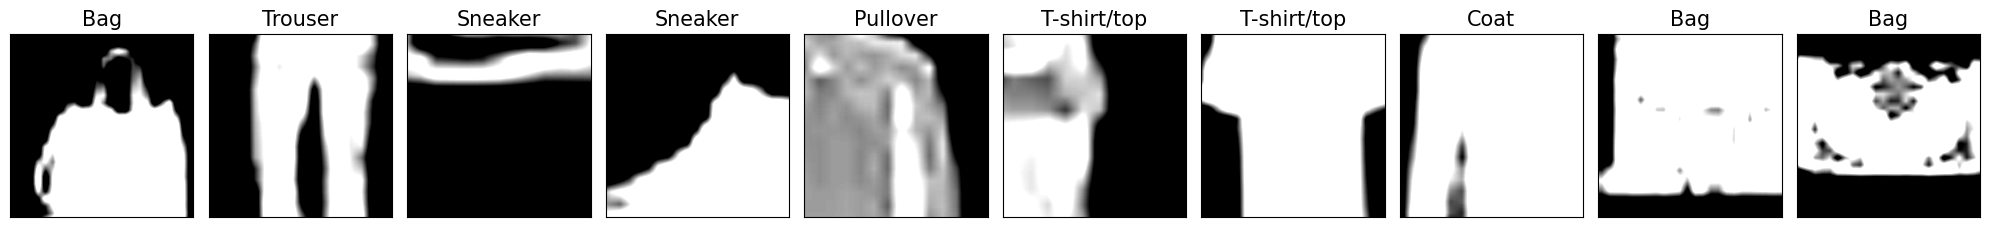

In [6]:
nsamples=10 # number of displayed images
imgs, labels = next(iter(train_loader))

fig=plt.figure(figsize=(20,5),facecolor='w')
for i in range(nsamples):
    ax = plt.subplot(1,nsamples, i+1)
    plt.imshow(imgs[i, 0, :, :], vmin=0, vmax=1.0, cmap=cm.gray)
    ax.set_title("{}".format(classes_names[labels[i]]), fontsize=15)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

#plt.savefig('fashionMNIST_samples.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## 4. Loading a pretrained model and adapting it to new data

### Load the pretrained ResNet-18 model

In [7]:
my_resnet = models.resnet18(pretrained=True)

C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Adapting to different channel sizes

The ResNet-18 model is trained on 3-channel RGB ImageNet data and expects the same format for input. Using images with a different number of channels without modification will result in an error. In this Notebook we are using 1-channel grayscale images.

1- Modify the first convolutional layer:

In [8]:
conv1 = torch.nn.Conv2d(num_channels, my_resnet.conv1.out_channels, kernel_size=my_resnet.conv1.kernel_size, stride=my_resnet.conv1.stride, padding=my_resnet.conv1.padding, bias=my_resnet.conv1.bias)

2- Initialize the New Layer’s Weights

A common practice is to initialize the new layer’s weights by averaging the original weight 
across the channel dimension:

In [9]:
original_weights = my_resnet.conv1.weight.data.mean(dim=1, keepdim=True)

conv1.weight.data = original_weights.repeat(1, num_channels, 1, 1)

3- Replace the Original Convolutional Layer

We swap out the original first convolutional layer with your new, channel-adapted one:

In [10]:
my_resnet.conv1 = conv1

### Adapting the output layer to the number of classes

Change the output layer to output 10 classes instead of 1000 classes, in ImageNet. The process follows almost the same stages:

In [11]:
num_ftrs = my_resnet.fc.in_features
num_classes = len(classes_names)
fc = torch.nn.Linear(num_ftrs, num_classes)
my_resnet.fc = fc
torch.nn.init.xavier_uniform_(my_resnet.fc.weight)

Parameter containing:
tensor([[ 0.0226, -0.0018, -0.0189,  ..., -0.0042,  0.1045, -0.0267],
        [-0.0942,  0.0444, -0.0583,  ...,  0.0847, -0.0821,  0.0650],
        [ 0.0945, -0.0457,  0.0252,  ...,  0.0070, -0.0863, -0.0229],
        ...,
        [ 0.0705, -0.0400, -0.0008,  ..., -0.0951,  0.0748,  0.0054],
        [ 0.0608, -0.0348, -0.0283,  ...,  0.0189,  0.0559,  0.0464],
        [ 0.0768, -0.0495, -0.0061,  ..., -0.0808,  0.0776,  0.0110]],
       requires_grad=True)

### Test the modified network

In [12]:
# Testing the network
input = torch.randn((32,1,224,224)) # the input images are 1x224x224 in a batch of size 32 for exemple
output = my_resnet(input)

### Display the model

In [13]:
# set model to device and visualize the model
model = my_resnet.to(device)

if str(device) == "cuda":
    print(summary(my_resnet,(batch_size, 1, 224, 224))) 
else:
    print(my_resnet)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 112, 112]        3,136
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

## 4. Training

### Metric calculation

In [14]:
def compute_classif_metrics(y_test,y_test_predictions):
    accuracy = accuracy_score(y_test, y_test_predictions)
    precision = precision_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    recall = recall_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    f1score = f1_score(y_test, y_test_predictions, average = 'macro', zero_division=np.nan)
    return accuracy, precision, recall, f1score

### Training


In [15]:
# loss function
loss_function = torch.nn.CrossEntropyLoss() # cross entropy works well for multi-class problems

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Number of batches for the training and validation sets
nb_train_batches = len(train_loader)
nb_valid_batches = len(valid_loader)

# loop for every epoch (training + evaluation)
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0

    # ----------------- TRAINING  -------------------- 
    # set model to training
    model.train()
    
    for i, data in enumerate(tqdm(train_loader)):
        X, y = data[0].to(device), data[1].to(device)
        
        # training step for single batch
        model.zero_grad()
        outputs = model(X)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizer.step()

        # getting training quality data
        current_loss = loss.item()
        total_train_loss += current_loss

    # releasing unceseccary memory in GPU
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ----------------- VALIDATION  ----------------- 
    total_val_loss = 0
    precision, recall, f1score, accuracy = [], [], [], []
    
    # set model to evaluating (testing)
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(valid_loader):
            X, y = data[0].to(device), data[1].to(device)

            outputs = model(X) # this get's the prediction from the network
            loss = loss_function(outputs, y)

            # getting validation quality data
            current_loss = loss.item()
            total_val_loss += current_loss
            
            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            
            # calculate P/R/F1/A metrics for batch
            acc, prec, rec, f1s = compute_classif_metrics(y.cpu(), predicted_classes.cpu())
            
            accuracy.append(acc)
            precision.append(prec)
            recall.append(rec)
            f1score.append(f1s)
          
    print(f"Epoch {epoch+1}/{num_epochs}, training loss: {total_train_loss/nb_train_batches}, validation loss: {total_val_loss/nb_valid_batches}")
    print(f"Accuracy =  %.4f, Precision =  %.4f, Recall =  %.4f, F1Score =  %.4f" % (np.sum(accuracy)/nb_valid_batches, np.sum(precision)/nb_valid_batches, np.sum(recall)/nb_valid_batches, np.sum(f1score)/nb_valid_batches))
    train_losses.append(total_train_loss/nb_train_batches) # for plotting learning curve
    valid_losses.append(total_val_loss/nb_valid_batches)

100%|██████████| 37/37 [01:05<00:00,  1.76s/it]


Epoch 1/20, training loss: 1.672211187916833, validation loss: 1.9865567949083116
Accuracy =  0.4097, Precision =  0.5131, Recall =  0.4178, F1Score =  0.3683


100%|██████████| 37/37 [00:16<00:00,  2.19it/s]


Epoch 2/20, training loss: 1.1706190431440198, validation loss: 1.1386700405014887
Accuracy =  0.5347, Precision =  0.6046, Recall =  0.5671, F1Score =  0.5124


100%|██████████| 37/37 [00:15<00:00,  2.43it/s]


...

Epoch 18/20, training loss: 0.7304723351388365, validation loss: 0.8123463988304138
Accuracy =  0.7326, Precision =  0.7364, Recall =  0.7475, F1Score =  0.7006


100%|██████████| 37/37 [00:13<00:00,  2.80it/s]


Epoch 19/20, training loss: 0.72035055627694, validation loss: 0.7925686240196228
Accuracy =  0.7153, Precision =  0.7180, Recall =  0.7119, F1Score =  0.6758


100%|██████████| 37/37 [00:12<00:00,  2.90it/s]


Epoch 20/20, training loss: 0.6496970436057529, validation loss: 0.9495388865470886
Accuracy =  0.6493, Precision =  0.6782, Recall =  0.6603, F1Score =  0.5965


### Display the losses

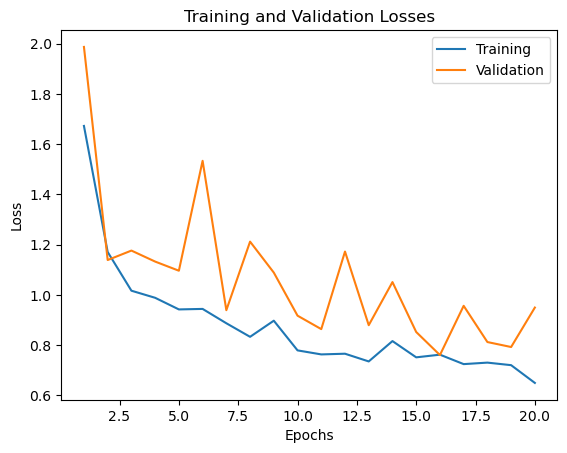

In [16]:
# Generate a sequence of integers to represent the epoch numbers
epochs = range(1, num_epochs+1)

# Plot and label the training and validation loss values
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')

# Add in a title and axes labels
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation']) 

plt.show()

### Save the model

In [17]:
torch.save(model.state_dict(), model_weigths_path + "resnet18_fine_tuned2_MNIST.pth")    

## From Scratch

In [18]:
my_resnet = models.resnet18(pretrained=False)
my_resnet.conv1 = torch.nn.Conv2d(num_channels, my_resnet.conv1.out_channels, kernel_size=my_resnet.conv1.kernel_size, stride=my_resnet.conv1.stride, padding=my_resnet.conv1.padding, bias=my_resnet.conv1.bias)
num_ftrs = my_resnet.fc.in_features
num_classes = len(classes_names)
fc = torch.nn.Linear(num_ftrs, num_classes)
my_resnet.fc = fc


C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [19]:
# set model to device 
model = my_resnet.to(device)

# Visualize the model
if str(device) == "cuda":
    print(summary(my_resnet,(batch_size, 3, 224, 224))) 
else:
    print(my_resnet)

# loss function
loss_function = torch.nn.CrossEntropyLoss() # cross entropy works well for multi-class problems

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Number of batches for the training and validation sets
nb_train_batches = len(train_loader)
nb_valid_batches = len(valid_loader)

# loop for every epoch (training + evaluation)
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0

    # ----------------- TRAINING  -------------------- 
    # set model to training
    model.train()
    
    for i, data in enumerate(tqdm(train_loader)):
        X, y = data[0].to(device), data[1].to(device)
        
        # training step for single batch
        model.zero_grad()
        outputs = model(X)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizer.step()

        # getting training quality data
        current_loss = loss.item()
        total_train_loss += current_loss

    # releasing unceseccary memory in GPU
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # ----------------- VALIDATION  ----------------- 
    total_val_loss = 0
    precision, recall, f1score, accuracy = [], [], [], []
    
    # set model to evaluating (testing)
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(valid_loader):
            X, y = data[0].to(device), data[1].to(device)

            outputs = model(X) # this get's the prediction from the network
            loss = loss_function(outputs, y)

            # getting validation quality data
            current_loss = loss.item()
            total_val_loss += current_loss
            
            predicted_classes = torch.max(outputs, 1)[1] # get class from network's prediction
            
            # calculate P/R/F1/A metrics for batch
            acc, prec, rec, f1s = compute_classif_metrics(y.cpu(), predicted_classes.cpu())
            
            accuracy.append(acc)
            precision.append(prec)
            recall.append(rec)
            f1score.append(f1s)
          
    print(f"Epoch {epoch+1}/{num_epochs}, training loss: {total_train_loss/nb_train_batches}, validation loss: {total_val_loss/nb_valid_batches}")
    print(f"Accuracy =  %.4f, Precision =  %.4f, Recall =  %.4f, F1Score =  %.4f" % (np.sum(accuracy)/nb_valid_batches, np.sum(precision)/nb_valid_batches, np.sum(recall)/nb_valid_batches, np.sum(f1score)/nb_valid_batches))
    train_losses.append(total_train_loss/nb_train_batches) # for plotting learning curve
    valid_losses.append(total_val_loss/nb_valid_batches)

100%|██████████| 37/37 [00:13<00:00,  2.66it/s]


Epoch 1/20, training loss: 0.9153347128146404, validation loss: 1.0264464683002896
Accuracy =  0.6319, Precision =  0.6747, Recall =  0.6328, F1Score =  0.5860


100%|██████████| 37/37 [00:13<00:00,  2.71it/s]


Epoch 2/20, training loss: 0.8135726959318728, validation loss: 0.9988022512859769
Accuracy =  0.6562, Precision =  0.7345, Recall =  0.6837, F1Score =  0.6301


100%|██████████| 37/37 [00:13<00:00,  2.70it/s]


...

Epoch 18/20, training loss: 0.6600945056290239, validation loss: 0.8219710654682584
Accuracy =  0.7326, Precision =  0.7653, Recall =  0.7513, F1Score =  0.7129


100%|██████████| 37/37 [00:12<00:00,  2.92it/s]


Epoch 19/20, training loss: 0.63011929231721, validation loss: 0.6883029209242927
Accuracy =  0.7326, Precision =  0.7776, Recall =  0.7443, F1Score =  0.7298


100%|██████████| 37/37 [00:12<00:00,  2.97it/s]


Epoch 20/20, training loss: 0.567283883690834, validation loss: 0.7475809819168515
Accuracy =  0.7535, Precision =  0.7816, Recall =  0.7594, F1Score =  0.7317


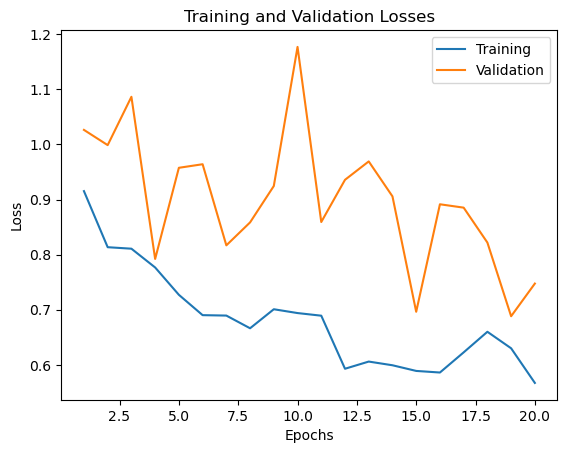

In [20]:
# Generate a sequence of integers to represent the epoch numbers
epochs = range(1, num_epochs+1)

# Plot and label the training and validation loss values
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')

# Add in a title and axes labels
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation']) 

plt.show()

In [21]:
torch.save(model.state_dict(), model_weigths_path + "resnet18_from_scratch_MNIST.pth")  